In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from mpl_toolkits.mplot3d import proj3d

plt.style.use('dark_background')

In [2]:
CSV_PATH = "SN_d_tot_V2.0.csv"

names = ["Year", "Month", "Day", "Decimal date",
         "Estimated Sunspot Number", "Estimated Standard Deviation",
         "Number of Stations calculated", "Number of Stations available"]

raw = pd.read_csv(CSV_PATH, delimiter=";", names=names)
raw["Date"] = pd.to_datetime(dict(year=raw.Year, month=raw.Month, day=raw.Day))

# -1 es el centinela SILSO de "sin observación": lo convertimos a NaN, no a "cero manchas".
raw.loc[raw["Estimated Sunspot Number"] < 0, "Estimated Sunspot Number"] = np.nan
raw.loc[raw["Estimated Standard Deviation"] < 0, "Estimated Standard Deviation"] = np.nan

print(f"Rango disponible: {raw.Date.min().date()} -> {raw.Date.max().date()}")
print(f"Días sin observación (NaN tras limpieza): {raw['Estimated Sunspot Number'].isna().sum()}")


Rango disponible: 1818-01-01 -> 2026-08-31
Días sin observación (NaN tras limpieza): 3247


In [3]:
DATE_START = "1850-01-01"   # inicio de ventana a animar (ajustable)
DATE_END = raw["Date"].max().strftime("%Y-%m-%d")
RESAMPLE = "3D"             # cadencia de remuestreo: "1D" (diario), "3D", "7D" (semanal)...
SMOOTH_WIN = 9               # ventana de suavizado móvil, en pasos de RESAMPLE

window = raw[(raw.Date >= DATE_START) & (raw.Date <= DATE_END)].copy()
window = window.set_index("Date").sort_index()
window["SSN"] = window["Estimated Sunspot Number"].interpolate(limit=10)

df = window["SSN"].resample(RESAMPLE).mean().to_frame("SSN")
df["SSN_smooth"] = df["SSN"].rolling(SMOOTH_WIN, center=True, min_periods=1).mean()
df = df.dropna(subset=["SSN_smooth"]).reset_index()

df["Year"] = df["Date"].dt.year
df["DayOfYear"] = df["Date"].dt.dayofyear
df["TotalDays"] = df["Date"].dt.is_leap_year.map({True: 366, False: 365})

print(f"Puntos a animar: {len(df)}  (de {DATE_START} a {DATE_END}, remuestreo {RESAMPLE})")
df.head()


Puntos a animar: 21509  (de 1850-01-01 a 2026-08-31, remuestreo 3D)


,Date,SSN,SSN_smooth,Year,DayOfYear,TotalDays
0,1850-01-01,210.666667,145.266667,1850,1,365
1,1850-01-04,136.666667,142.000000,1850,4,365
2,1850-01-07,104.333333,134.476190,1850,7,365
3,1850-01-10,158.000000,131.458333,1850,10,365
4,1850-01-13,116.666667,144.222222,1850,13,365


In [4]:
df.set_index("Date")

,SSN,SSN_smooth,Year,DayOfYear,TotalDays
Date,,,,,
1850-01-01,210.666667,145.266667,1850,1,365
1850-01-04,136.666667,142.000000,1850,4,365
1850-01-07,104.333333,134.476190,1850,7,365
1850-01-10,158.000000,131.458333,1850,10,365
1850-01-13,116.666667,144.222222,1850,13,365
...,...,...,...,...,...
2026-08-18,66.333333,71.000000,2026,230,365
2026-08-21,75.666667,73.541667,2026,233,365
2026-08-24,85.000000,78.904762,2026,236,365


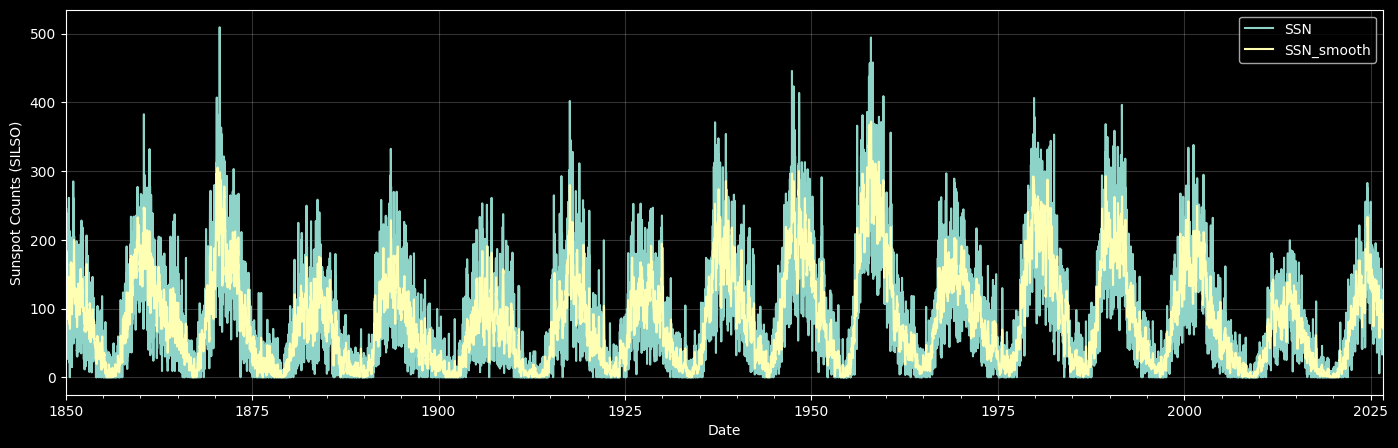

In [5]:
df.set_index("Date")["SSN"].plot(figsize=(17,5))
df.set_index("Date")["SSN_smooth"].plot(figsize=(17,5))
plt.legend();plt.grid(alpha=0.2);plt.ylabel("Sunspot Counts (SILSO)")
plt.show()

In [13]:
SOLAR_CYCLE_STARTS = {  # inicios de ciclo solar aproximados (SIDC), ciclos 21-25
                        # https://en.wikipedia.org/wiki/List_of_solar_cycles
    10: "1855-12-01", 11: "1867-03-01", 
    12: "1878-12-01", 13: "1890-03-01", 14: "1902-01-01", 
    15: "1913-07-01", 16: "1923-08-01", 17: "1933-10-01", 
    18: "1944-02-01", 19: "1954-04-01", 20: "1964-10-01", 
    21: "1976-03-01", 22: "1986-09-01", 23: "1996-08-01",
    24: "2008-12-01", "25\n(Current)": "2019-12-01",
}

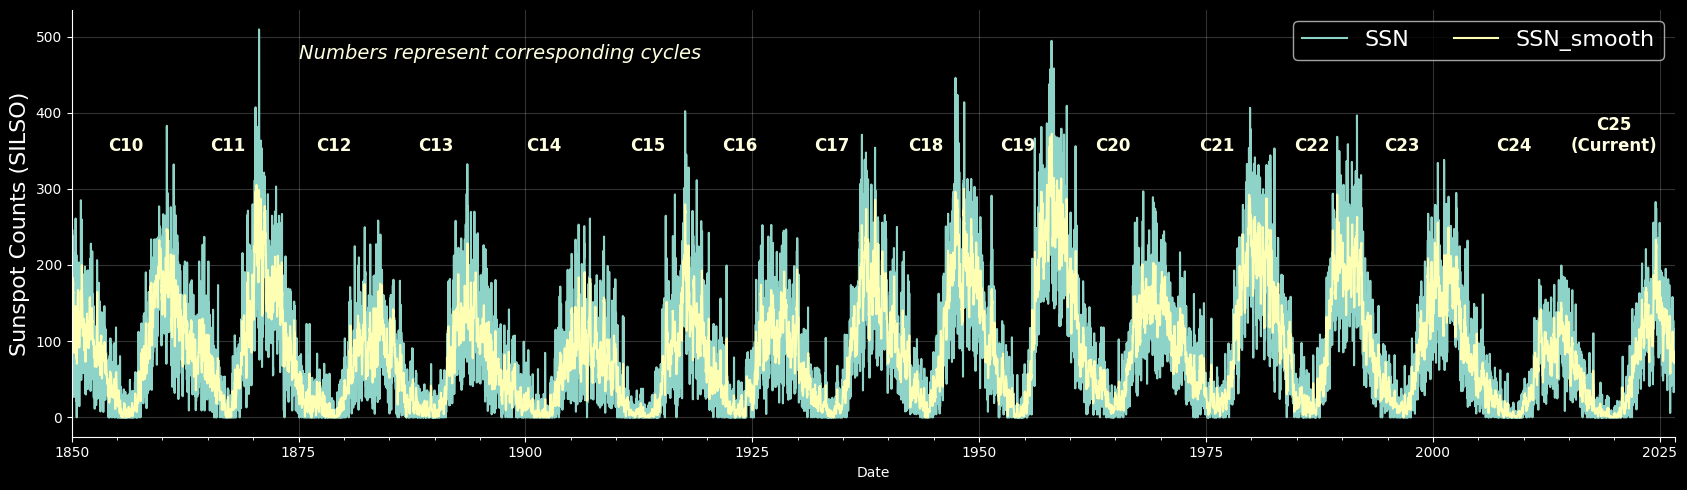

In [14]:
ci=pd.DataFrame([SOLAR_CYCLE_STARTS])
df.set_index("Date")["SSN"].plot(figsize=(17,5))
df.set_index("Date")["SSN_smooth"].plot(figsize=(17,5))
plt.legend(fontsize=16,ncol=2);plt.grid(alpha=0.2);plt.ylabel("Sunspot Counts (SILSO)",fontsize=16)
plt.text("1875-01-01",470,"Numbers represent corresponding cycles",fontsize=14,weight="normal",c="lightyellow",style="italic",stretch='ultra-condensed')
for i in ci[1:]:
    plt.text(ci.loc[:, i][0],350,"C"+str(ci.loc[:, i].name),ha="center",weight="bold",c="lightyellow",fontsize=12)
    #print(ci.loc[:, i][0],400,"Cycle "+str(ci.loc[:, i].name))
# --- QUITAR LOS EJES SUPERIOR Y DERECHO ---
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("sunspot_timeserie.png",dpi=250,bbox_inches='tight',transparent=True)
plt.show()